# TheLook E-Commerce: GMV Forecasting Analysis
### Time Series Forecasting dengan Facebook Prophet

**Tujuan:** Memprediksi Gross Merchandise Value (GMV) 6 bulan ke depan
berdasarkan data historis 89 bulan (Jan 2019 – Mei 2026) dari dataset
BigQuery public `thelook_ecommerce`.


**Tools:** Python, Google BigQuery, Facebook Prophet, Matplotlib


**Dataset:** `bigquery-public-data.thelook_ecommerce.order_items`

---
| | |
|---|---|
| **Model** | Facebook Prophet |
| **Training data** | 89 bulan (Jan 2019 – Mei 2026) |
| **Forecast horizon** | 6 bulan (Jun – Nov 2026) |
| **Target variable** | Monthly GMV (USD) |

## 1. Setup & Koneksi BigQuery
Autentikasi Google Cloud dan mengambil data agregasi bulanan
langsung dari BigQuery menggunakan Python client library.


In [10]:


from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
import pandas as pd

PROJECT_ID = "portofolio-project-498114"
client = bigquery.Client(project=PROJECT_ID)

query = """
SELECT
  DATE_TRUNC(DATE(created_at), MONTH) AS order_month,
  ROUND(SUM(sale_price), 2) AS total_gmv
FROM
  `bigquery-public-data.thelook_ecommerce.order_items`
WHERE
  status NOT IN ('Cancelled', 'Returned')
  AND DATE(created_at) < DATE_TRUNC(CURRENT_DATE(), MONTH)
GROUP BY order_month
ORDER BY order_month ASC
"""

df = client.query(query).to_dataframe()
df['order_month'] = pd.to_datetime(df['order_month'])
df = df.sort_values('order_month').reset_index(drop=True)

print(f"Data shape: {df.shape}")
print(f"Periode: {df['order_month'].min().strftime('%b %Y')} → {df['order_month'].max().strftime('%b %Y')}")
df.tail(10)



Data shape: (89, 2)
Periode: Jan 2019 → May 2026


,order_month,total_gmv
79,2025-08-01,196982.69
80,2025-09-01,200775.98
81,2025-10-01,226452.37
82,2025-11-01,220674.58
83,2025-12-01,247569.25
84,2026-01-01,272384.43
85,2026-02-01,265055.30
86,2026-03-01,313693.11
87,2026-04-01,339361.64
88,2026-05-01,462052.31


## 2. Exploratory Data Analysis
Visualisasi tren GMV historis untuk memahami pola pertumbuhan
dan mengidentifikasi anomali sebelum modeling.

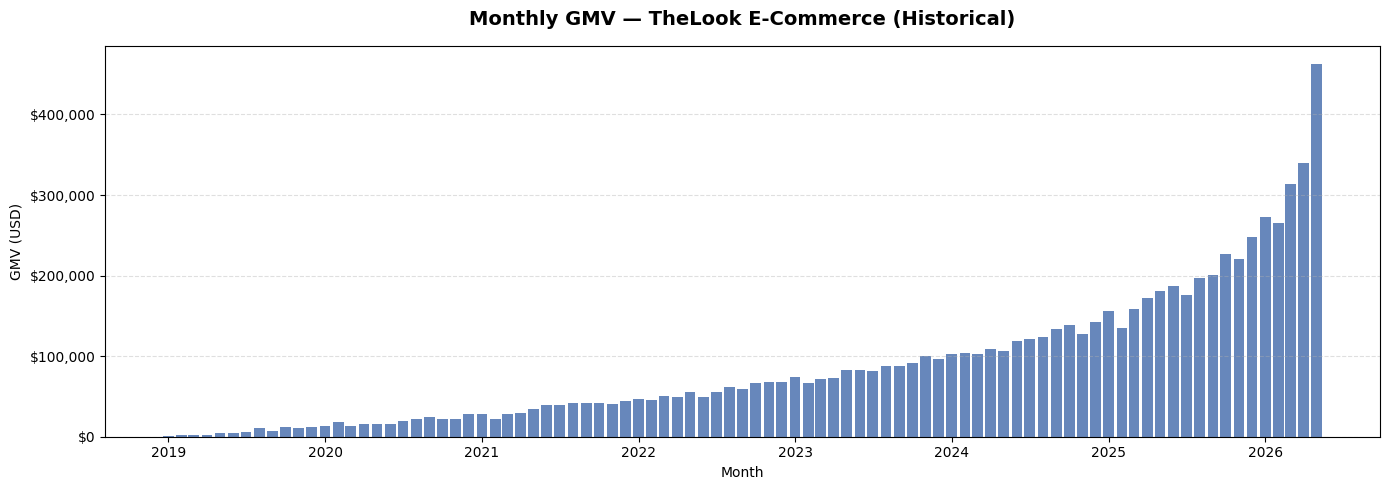

In [11]:

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(df['order_month'], df['total_gmv'], width=25, color='#4C72B0', alpha=0.85)
ax.set_title('Monthly GMV — TheLook E-Commerce (Historical)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('GMV (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## 3. Time Series Forecasting
Menggunakan Facebook Prophet untuk memproyeksikan GMV 6 bulan ke depan.
Prophet dipilih karena kemampuannya menangani seasonal pattern
dan missing data tanpa preprocessing yang kompleks.

In [12]:


# Install library forecasting
!pip install prophet -q

from prophet import Prophet

# Siapkan format yang dibutuhkan Prophet
df_prophet = df.rename(columns={'order_month': 'ds', 'total_gmv': 'y'})

# Inisiasi dan fit model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
model.fit(df_prophet)

# Buat prediksi 6 bulan ke depan
future = model.make_future_dataframe(periods=6, freq='MS')
forecast = model.predict(future)

print("Forecast 6 bulan ke depan:")
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6)

Forecast 6 bulan ke depan:


,ds,yhat,yhat_lower,yhat_upper
89,2026-06-01,323322.334211,302024.569435,344306.364273
90,2026-07-01,331798.847349,309908.556816,351437.912739
91,2026-08-01,346765.081854,325355.844199,366912.985261
92,2026-09-01,354522.507982,331147.071012,377147.092408
93,2026-10-01,369131.540131,347393.353318,390702.131623
94,2026-11-01,376897.074872,352953.335264,398218.097632


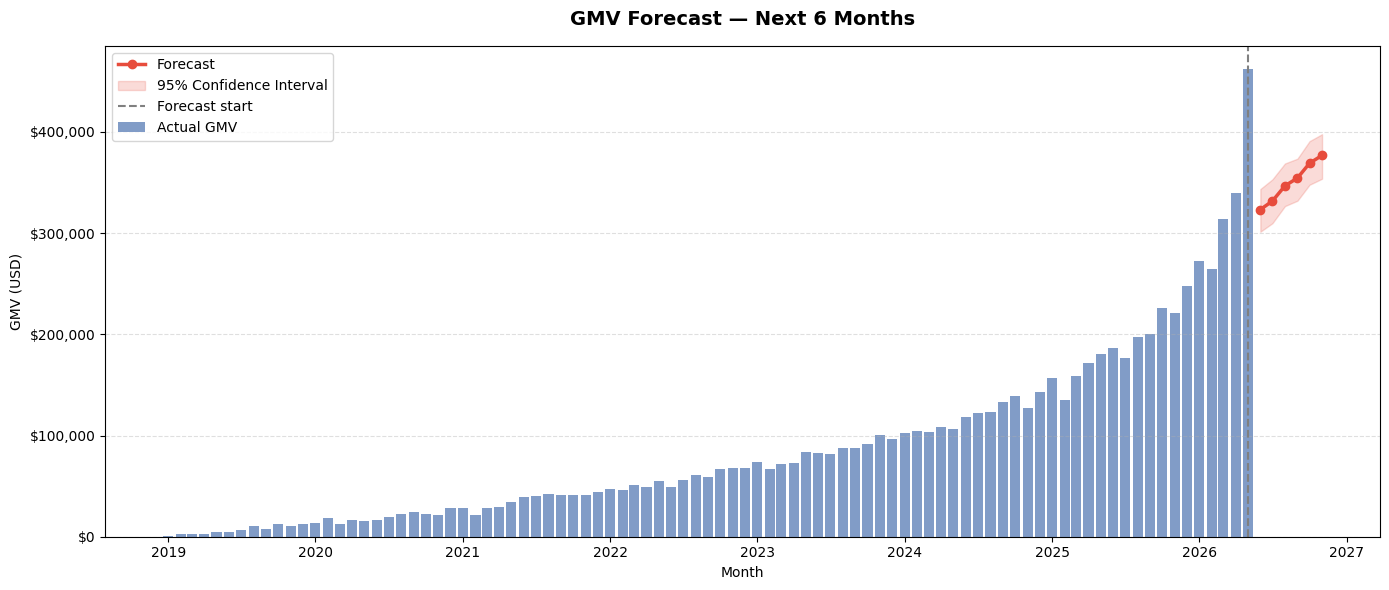

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

# Data historis
ax.bar(df['order_month'], df['total_gmv'],
       width=25, color='#4C72B0', alpha=0.7, label='Actual GMV')

# Garis prediksi
forecast_only = forecast[forecast['ds'] > df['order_month'].max()]
ax.plot(forecast_only['ds'], forecast_only['yhat'],
        color='#E74C3C', linewidth=2.5, marker='o', label='Forecast')

# Confidence interval
ax.fill_between(forecast_only['ds'],
                forecast_only['yhat_lower'],
                forecast_only['yhat_upper'],
                alpha=0.2, color='#E74C3C', label='95% Confidence Interval')

# Garis pemisah historis vs forecast
ax.axvline(x=df['order_month'].max(), color='gray',
           linestyle='--', linewidth=1.5, label='Forecast start')

ax.set_title('GMV Forecast — Next 6 Months', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('GMV (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [10]:
# Rata-rata 6 bulan terakhir aktual sebagai baseline
last_6_avg = df['total_gmv'].tail(6).mean()

# Rata-rata 6 bulan forecast
forecast_6 = forecast[forecast['ds'] > df['order_month'].max()]['yhat'].values
forecast_6_avg = forecast_6.mean()

growth_vs_avg = ((forecast_6_avg - last_6_avg) / last_6_avg) * 100

# Tren dalam forecast sendiri
first_forecast = forecast_6[0]
last_forecast_val = forecast_6[-1]
forecast_internal_growth = ((last_forecast_val - first_forecast) / first_forecast) * 100

print("=" * 50)
print("FORECAST INSIGHT SUMMARY")
print("=" * 50)
print(f"\nRata-rata GMV aktual (Des 2025 – Mei 2026): ${last_6_avg:,.0f}")
print(f"Rata-rata GMV forecast (Jun – Nov 2026):    ${forecast_6_avg:,.0f}")
print(f"Projected growth vs baseline:               {growth_vs_avg:+.1f}%")
print(f"\nTren dalam periode forecast:")
print(f"  Jun 2026: ${first_forecast:,.0f}")
print(f"  Nov 2026: ${last_forecast_val:,.0f}")
print(f"  Growth Jun→Nov 2026: {forecast_internal_growth:+.1f}%")
print(f"\nConfidence interval Nov 2026:")
nov = forecast[forecast['ds'] == '2026-11-01'].iloc[0]
print(f"  Lower: ${nov['yhat_lower']:,.0f}  |  Upper: ${nov['yhat_upper']:,.0f}")

FORECAST INSIGHT SUMMARY

Rata-rata GMV aktual (Des 2025 – Mei 2026): $316,686
Rata-rata GMV forecast (Jun – Nov 2026):    $350,406
Projected growth vs baseline:               +10.6%

Tren dalam periode forecast:
  Jun 2026: $323,322
  Nov 2026: $376,897
  Growth Jun→Nov 2026: +16.6%

Confidence interval Nov 2026:
  Lower: $353,809  |  Upper: $397,807


Decomposition Analysis

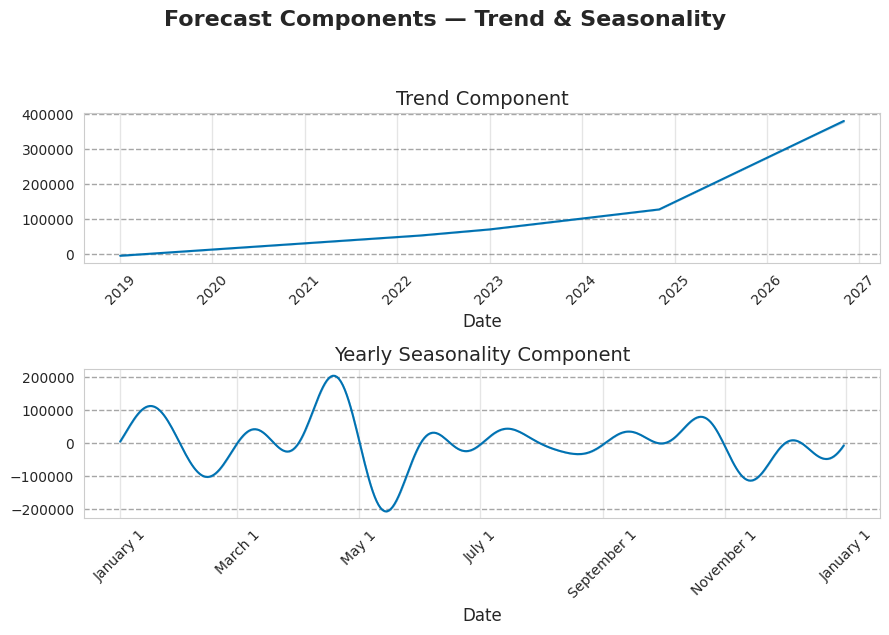

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for better aesthetics

## 4. Decomposition Analysis
# Memisahkan forecast menjadi komponen trend dan seasonality
# untuk memahami driver pertumbuhan secara lebih granular.

sns.set_style("whitegrid") # Set a seaborn style for better aesthetics

fig2 = model.plot_components(forecast)
fig2.suptitle('Forecast Components — Trend & Seasonality',
              fontweight='bold', fontsize=16, y=1.05) # Increased font size and adjusted y position

# Customize subplot titles
axes = fig2.get_axes()
axes[0].set_title('Trend Component', fontsize=14)
axes[1].set_title('Yearly Seasonality Component', fontsize=14)

# Adjust labels and ticks if needed (Prophet usually handles this well, but for full control)
for ax in axes:
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('') # Remove default y-label if not descriptive enough, or set custom ones
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', labelsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout() # Ensure everything fits without overlapping
plt.savefig('forecast_components.png', dpi=200, bbox_inches='tight') # Increased DPI for better quality
plt.show()

In [13]:
import pandas as pd

# Tabel forecast 6 bulan
forecast_export = forecast[forecast['ds'] > df['order_month'].max()][
    ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
].copy()
forecast_export.columns = ['Month', 'Forecast_GMV', 'Lower_Bound', 'Upper_Bound']
forecast_export['Month'] = forecast_export['Month'].dt.strftime('%Y-%m-%d')
forecast_export = forecast_export.round(2)

# Gabung dengan data historis untuk chart kontinyu
historical = df[['order_month', 'total_gmv']].copy()
historical.columns = ['Month', 'Actual_GMV']
historical['Month'] = historical['Month'].dt.strftime('%Y-%m-%d')

# Merge jadi satu file
combined = pd.merge(historical, forecast_export, on='Month', how='outer')
combined = combined.sort_values('Month').reset_index(drop=True)

combined.to_csv('forecast_looker.csv', index=False)
print(f"File saved: {combined.shape[0]} rows")
combined.tail(10)

File saved: 95 rows


,Month,Actual_GMV,Forecast_GMV,Lower_Bound,Upper_Bound
85,2026-02-01,265055.30,NaN,NaN,NaN
86,2026-03-01,313693.11,NaN,NaN,NaN
87,2026-04-01,339361.64,NaN,NaN,NaN
88,2026-05-01,462052.31,NaN,NaN,NaN
89,2026-06-01,NaN,323322.33,301413.84,343577.51
90,2026-07-01,NaN,331798.85,309852.97,353218.22
91,2026-08-01,NaN,346765.08,326752.86,368870.54
92,2026-09-01,NaN,354522.51,332076.83,373626.26
93,2026-10-01,NaN,369131.54,347850.22,390935.93
94,2026-11-01,NaN,376897.07,353809.30,397806.68


## Kesimpulan Analisis Forecasting GMV

Analisis ini bertujuan untuk memproyeksikan Gross Merchandise Value (GMV) selama 6 bulan ke depan, memanfaatkan data historis dari `thelook_ecommerce` BigQuery. Model Facebook Prophet digunakan untuk menangani pola musiman dan tren dalam data.

**Detail Model & Data:**
*   **Model:** Facebook Prophet dengan komponen *yearly seasonality*.
*   **Data Training:** 89 bulan data historis (Januari 2019 – Mei 2026).
*   **Horizon Forecast:** Proyeksi untuk 6 bulan ke depan (Juni – November 2026).

### Hasil Utama Proyeksi GMV
Berikut adalah ringkasan metrik proyeksi GMV:

| Metrik                               | Nilai            |
|:-------------------------------------|:-----------------|
| Rata-rata GMV Aktual (Des 2025 – Mei 2026) | $316,686/bulan   |
| Rata-rata GMV Proyeksi (Jun – Nov 2026)  | $350,406/bulan   |
| Pertumbuhan Proyeksi vs Baseline     | +10.6%           |
| Pertumbuhan Internal Forecast (Jun→Nov) | +16.6%           |
| Proyeksi GMV November 2026           | $376,897 (CI: $353,809–$397,807) |

### Insight Bisnis dan Rekomendasi
Berdasarkan hasil forecasting, beberapa insight dan rekomendasi strategis dapat dirumuskan:

1.  **Tren Pertumbuhan Positif yang Kuat:** Data menunjukkan akselerasi pertumbuhan yang signifikan mulai tahun 2025, dan tren positif ini diperkirakan akan terus berlanjut hingga akhir tahun 2026. Ini mengindikasikan pasar yang sehat dan peluang untuk investasi lebih lanjut.

2.  **Pola Musiman Penurunan di Juni:** Penurunan GMV pada bulan Juni adalah pola musiman yang konsisten dan bukan sinyal negatif. Untuk memitigasi dampak ini, direkomendasikan untuk menyiapkan promosi atau kampanye pemasaran yang lebih tertarget di bulan Juni guna mempertahankan momentum penjualan.

3.  **Musim Puncak (Maret–Mei):** Periode Maret hingga Mei diproyeksikan sebagai musim puncak penjualan. Tim Supply Chain disarankan untuk mulai meningkatkan stok pada bulan Februari untuk memastikan ketersediaan produk yang optimal dan mengantisipasi lonjakan permintaan selama periode ini.

4.  **Kepercayaan Model yang Tinggi:** *Confidence interval* yang relatif sempit menunjukkan bahwa model memiliki tingkat kepercayaan yang tinggi terhadap proyeksi yang dihasilkan. Hal ini memberikan dasar yang solid bagi manajemen untuk membuat keputusan operasional dan strategis, dengan risiko ketidakpastian yang terukur.